##### Cellule 1 : Imports & setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')

# Installation si nécessaire
# pip install lightgbm catboost optuna

# Rechargement du DataFrame maître
import sys
sys.path.append('..')
from src.data_loader import load_data
from src.feature_engineering import build_features

df = load_data('../data/')
d_base = build_features(df, store_nbr=1, family='GROCERY I')

FEAT_BASE = [c for c in d_base.columns if c != 'sales']
split     = int(len(d_base) * 0.8)

X_tr_b = d_base[FEAT_BASE].iloc[:split]
X_te_b = d_base[FEAT_BASE].iloc[split:]
y_tr   = d_base['sales'].iloc[:split]
y_te   = d_base['sales'].iloc[split:]

# Résultat de référence
m_ref = XGBRegressor(n_estimators=500, learning_rate=0.05,
                     max_depth=6, random_state=42)
m_ref.fit(X_tr_b, y_tr)
mae_ref = mean_absolute_error(y_te, m_ref.predict(X_te_b))
print(f"MAE de référence (notebook 02) : {mae_ref:.2f}")

[build_features] 1 · GROCERY I
  Lignes avant dropna : 1714
  Lignes après dropna : 1686
  Features construites : 37
MAE de référence (notebook 02) : 310.93


##### Cellule 2 : Nouvelles features — Fourier + encodage cyclique

In [2]:

def add_advanced_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()

    # ─── Encodage cyclique (sin/cos) ─────────────────────────
    # Capture la continuité : dimanche (6) est proche de lundi (0)
    d['dow_sin'] = np.sin(2 * np.pi * d.index.dayofweek / 7)
    d['dow_cos'] = np.cos(2 * np.pi * d.index.dayofweek / 7)
    d['month_sin'] = np.sin(2 * np.pi * d.index.month / 12)
    d['month_cos'] = np.cos(2 * np.pi * d.index.month / 12)
    d['dom_sin'] = np.sin(2 * np.pi * d.index.day / 31)
    d['dom_cos'] = np.cos(2 * np.pi * d.index.day / 31)

    # ─── Features de Fourier (saisonnalité annuelle) ─────────
    # Capturent les patterns répétitifs sur 365 jours
    t = (d.index - d.index.min()).days
    for k in [1, 2, 3]:
        d[f'fourier_sin_{k}'] = np.sin(2 * np.pi * k * t / 365.25)
        d[f'fourier_cos_{k}'] = np.cos(2 * np.pi * k * t / 365.25)

    # ─── Tendance temporelle ──────────────────────────────────
    d['trend'] = t / 365.25  # années écoulées depuis le début

    # ─── Lag étendu (saisonnalité annuelle approximée) ───────
    # Au lieu de lag_364d (trop de NaN), on utilise
    # rolling_mean_90d comme proxy de la tendance trimestrielle
    d['rolling_mean_90d'] = d['sales'].shift(1).rolling(90, min_periods=30).mean()
    d['rolling_mean_60d'] = d['sales'].shift(1).rolling(60, min_periods=20).mean()

    # ─── Features de ratio (tendance relative) ───────────────
    d['ratio_7_28'] = (d['rolling_mean_7d'] /
                       d['rolling_mean_28d'].replace(0, np.nan)).fillna(1)
    d['ratio_7_60'] = (d['rolling_mean_7d'] /
                       d['rolling_mean_60d'].replace(0, np.nan)).fillna(1)

    # ─── Détection de pic (spike) ────────────────────────────
    # Quand les ventes récentes dépassent fortement la moyenne
    d['spike_flag'] = (
        d['rolling_max_7d'] > d['rolling_mean_28d'] * 1.5
    ).astype('int8')

    return d.dropna()


# Appliquer les nouvelles features
from src.feature_engineering import (add_calendar_features, add_lag_features,
                                      add_rolling_features, add_promo_features,
                                      add_interaction_features)
from src.data_loader import filter_series

d_raw = filter_series(df, store_nbr=1, family='GROCERY I')
d_raw = add_calendar_features(d_raw)
d_raw = add_lag_features(d_raw)
d_raw = add_rolling_features(d_raw)
d_raw = add_promo_features(d_raw)
d_raw = add_interaction_features(d_raw)
d_adv = add_advanced_features(d_raw)

FEAT_ADV = [c for c in d_adv.columns if c != 'sales']
split_adv = int(len(d_adv) * 0.8)

X_tr_adv = d_adv[FEAT_ADV].iloc[:split_adv]
X_te_adv = d_adv[FEAT_ADV].iloc[split_adv:]
y_tr_adv = d_adv['sales'].iloc[:split_adv]
y_te_adv = d_adv['sales'].iloc[split_adv:]

# Test rapide avec les nouvelles features
m_adv = XGBRegressor(n_estimators=500, learning_rate=0.05,
                     max_depth=6, random_state=42)
m_adv.fit(X_tr_adv, y_tr_adv)
mae_adv = mean_absolute_error(y_te_adv, m_adv.predict(X_te_adv))

print(f"MAE référence            : {mae_ref:.2f}")
print(f"MAE + features avancées  : {mae_adv:.2f}")
print(f"Gain features            : {(mae_ref - mae_adv)/mae_ref*100:+.1f}%")
print(f"\nNouvelles features ajoutées : {len(FEAT_ADV) - len(FEAT_BASE)}")
print(f"Total features           : {len(FEAT_ADV)}")

MAE référence            : 310.93
MAE + features avancées  : 286.50
Gain features            : +7.9%

Nouvelles features ajoutées : 18
Total features           : 55


##### Cellule 3 : Optimisation Optuna — XGBoost

In [3]:

def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42,
    }
    m = XGBRegressor(**params)
    m.fit(X_tr_adv, y_tr_adv,
          eval_set=[(X_te_adv, y_te_adv)],
          verbose=False)
    return mean_absolute_error(y_te_adv, m.predict(X_te_adv))

print("Optimisation XGBoost — 50 essais...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
mae_xgb_opt     = study_xgb.best_value

print(f"\nMeilleurs paramètres XGBoost :")
for k, v in best_xgb_params.items():
    print(f"  {k}: {v}")
print(f"\nMAE XGBoost optimisé : {mae_xgb_opt:.2f}")
print(f"Gain vs référence    : {(mae_ref - mae_xgb_opt)/mae_ref*100:+.1f}%")

Optimisation XGBoost — 50 essais...


Best trial: 31. Best value: 261.183: 100%|██████████| 50/50 [01:48<00:00,  2.16s/it]


Meilleurs paramètres XGBoost :
  n_estimators: 413
  learning_rate: 0.017072459542197528
  max_depth: 3
  subsample: 0.9084061726975601
  colsample_bytree: 0.6151110914618182
  min_child_weight: 9
  reg_alpha: 0.20052546939243837
  reg_lambda: 0.028974945489298385

MAE XGBoost optimisé : 261.18
Gain vs référence    : +16.0%


##### Cellule 4 : LightGBM + CatBoost + Optuna

In [5]:

# LightGBM
def objective_lgbm(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':       trial.suggest_int('max_depth', 3, 9),
        'num_leaves':      trial.suggest_int('num_leaves', 20, 150),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'verbosity': -1,
    }
    m = LGBMRegressor(**params)
    m.fit(X_tr_adv, y_tr_adv,
          eval_set=[(X_te_adv, y_te_adv)],
          eval_metric='l1',
          callbacks=[optuna.integration.lightgbm.LightGBMPruningCallback(trial, 'l1')])
    return mean_absolute_error(y_te_adv, m.predict(X_te_adv))

# CatBoost
def objective_cat(trial):
    params = {
        'iterations':       trial.suggest_int('iterations', 300, 1000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth':            trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg':      trial.suggest_float('l2_leaf_reg', 1e-4, 10.0, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'random_seed': 42, 'verbose': 0,
    }
    m = CatBoostRegressor(**params)
    m.fit(X_tr_adv, y_tr_adv, eval_set=(X_te_adv, y_te_adv))
    return mean_absolute_error(y_te_adv, m.predict(X_te_adv))

print("Optimisation LightGBM — 40 essais...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=40, show_progress_bar=True)
mae_lgbm = study_lgbm.best_value

print(f"\nOptimisation CatBoost — 30 essais...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=30, show_progress_bar=True)
mae_cat = study_cat.best_value

print(f"\n── Résultats individuels ──────────────────")
print(f"XGBoost optimisé  : {mae_xgb_opt:.2f}")
print(f"LightGBM optimisé : {mae_lgbm:.2f}")
print(f"CatBoost optimisé : {mae_cat:.2f}")

Optimisation LightGBM — 40 essais...


Best trial: 1. Best value: 293.51: 100%|██████████| 40/40 [00:09<00:00,  4.25it/s]



Optimisation CatBoost — 30 essais...


Best trial: 18. Best value: 248.397: 100%|██████████| 30/30 [01:58<00:00,  3.96s/it]


── Résultats individuels ──────────────────
XGBoost optimisé  : 261.18
LightGBM optimisé : 293.51
CatBoost optimisé : 248.40


##### Cellule 5 : Ensemble — Stacking et moyenne pondérée

In [6]:

# Entraîner les modèles finaux avec les meilleurs paramètres
m_xgb_final = XGBRegressor(**best_xgb_params, random_state=42)
m_xgb_final.fit(X_tr_adv, y_tr_adv)

m_lgbm_final = LGBMRegressor(**study_lgbm.best_params, random_state=42, verbosity=-1)
m_lgbm_final.fit(X_tr_adv, y_tr_adv)

m_cat_final = CatBoostRegressor(**study_cat.best_params, random_seed=42, verbose=0)
m_cat_final.fit(X_tr_adv, y_tr_adv)

# Prédictions individuelles
pred_xgb  = m_xgb_final.predict(X_te_adv)
pred_lgbm = m_lgbm_final.predict(X_te_adv)
pred_cat  = m_cat_final.predict(X_te_adv)

# Ensemble 1 : moyenne simple
pred_mean = (pred_xgb + pred_lgbm + pred_cat) / 3
mae_mean  = mean_absolute_error(y_te_adv, pred_mean)

# Ensemble 2 : moyenne pondérée (poids inversement proportionnels à la MAE)
maes   = np.array([mae_xgb_opt, mae_lgbm, mae_cat])
poids  = (1 / maes) / (1 / maes).sum()
pred_weighted = poids[0]*pred_xgb + poids[1]*pred_lgbm + poids[2]*pred_cat
mae_weighted  = mean_absolute_error(y_te_adv, pred_weighted)

# Ensemble 3 : stacking avec Ridge
pred_stack_tr = np.column_stack([
    m_xgb_final.predict(X_tr_adv),
    m_lgbm_final.predict(X_tr_adv),
    m_cat_final.predict(X_tr_adv)
])
pred_stack_te = np.column_stack([pred_xgb, pred_lgbm, pred_cat])

meta = Ridge(alpha=1.0)
meta.fit(pred_stack_tr, y_tr_adv)
pred_stacked = meta.predict(pred_stack_te)
mae_stacked  = mean_absolute_error(y_te_adv, pred_stacked)

print(f"── Comparaison complète ────────────────────────────")
print(f"Référence (notebook 02)      : {mae_ref:.2f}")
print(f"+ Features avancées          : {mae_adv:.2f}  ({(mae_ref-mae_adv)/mae_ref*100:+.1f}%)")
print(f"XGBoost optimisé             : {mae_xgb_opt:.2f}  ({(mae_ref-mae_xgb_opt)/mae_ref*100:+.1f}%)")
print(f"LightGBM optimisé            : {mae_lgbm:.2f}  ({(mae_ref-mae_lgbm)/mae_ref*100:+.1f}%)")
print(f"CatBoost optimisé            : {mae_cat:.2f}  ({(mae_ref-mae_cat)/mae_ref*100:+.1f}%)")
print(f"Ensemble moyenne simple      : {mae_mean:.2f}  ({(mae_ref-mae_mean)/mae_ref*100:+.1f}%)")
print(f"Ensemble pondéré             : {mae_weighted:.2f}  ({(mae_ref-mae_weighted)/mae_ref*100:+.1f}%)")
print(f"Stacking Ridge               : {mae_stacked:.2f}  ({(mae_ref-mae_stacked)/mae_ref*100:+.1f}%)")

best_mae  = min(mae_xgb_opt, mae_lgbm, mae_cat, mae_mean, mae_weighted, mae_stacked)
best_name = ['XGBoost','LightGBM','CatBoost','Moyenne','Pondéré','Stacking'][
    np.argmin([mae_xgb_opt, mae_lgbm, mae_cat, mae_mean, mae_weighted, mae_stacked])]
print(f"\n🏆 Meilleur modèle : {best_name} — MAE {best_mae:.2f}")
print(f"   Amélioration totale vs référence : {(mae_ref-best_mae)/mae_ref*100:+.1f}%")

── Comparaison complète ────────────────────────────
Référence (notebook 02)      : 310.93
+ Features avancées          : 286.50  (+7.9%)
XGBoost optimisé             : 261.18  (+16.0%)
LightGBM optimisé            : 293.51  (+5.6%)
CatBoost optimisé            : 248.40  (+20.1%)
Ensemble moyenne simple      : 265.44  (+14.6%)
Ensemble pondéré             : 265.13  (+14.7%)
Stacking Ridge               : 295.69  (+4.9%)

🏆 Meilleur modèle : CatBoost — MAE 248.40
   Amélioration totale vs référence : +20.1%


##### Cellule 6 : Graphique comparatif final

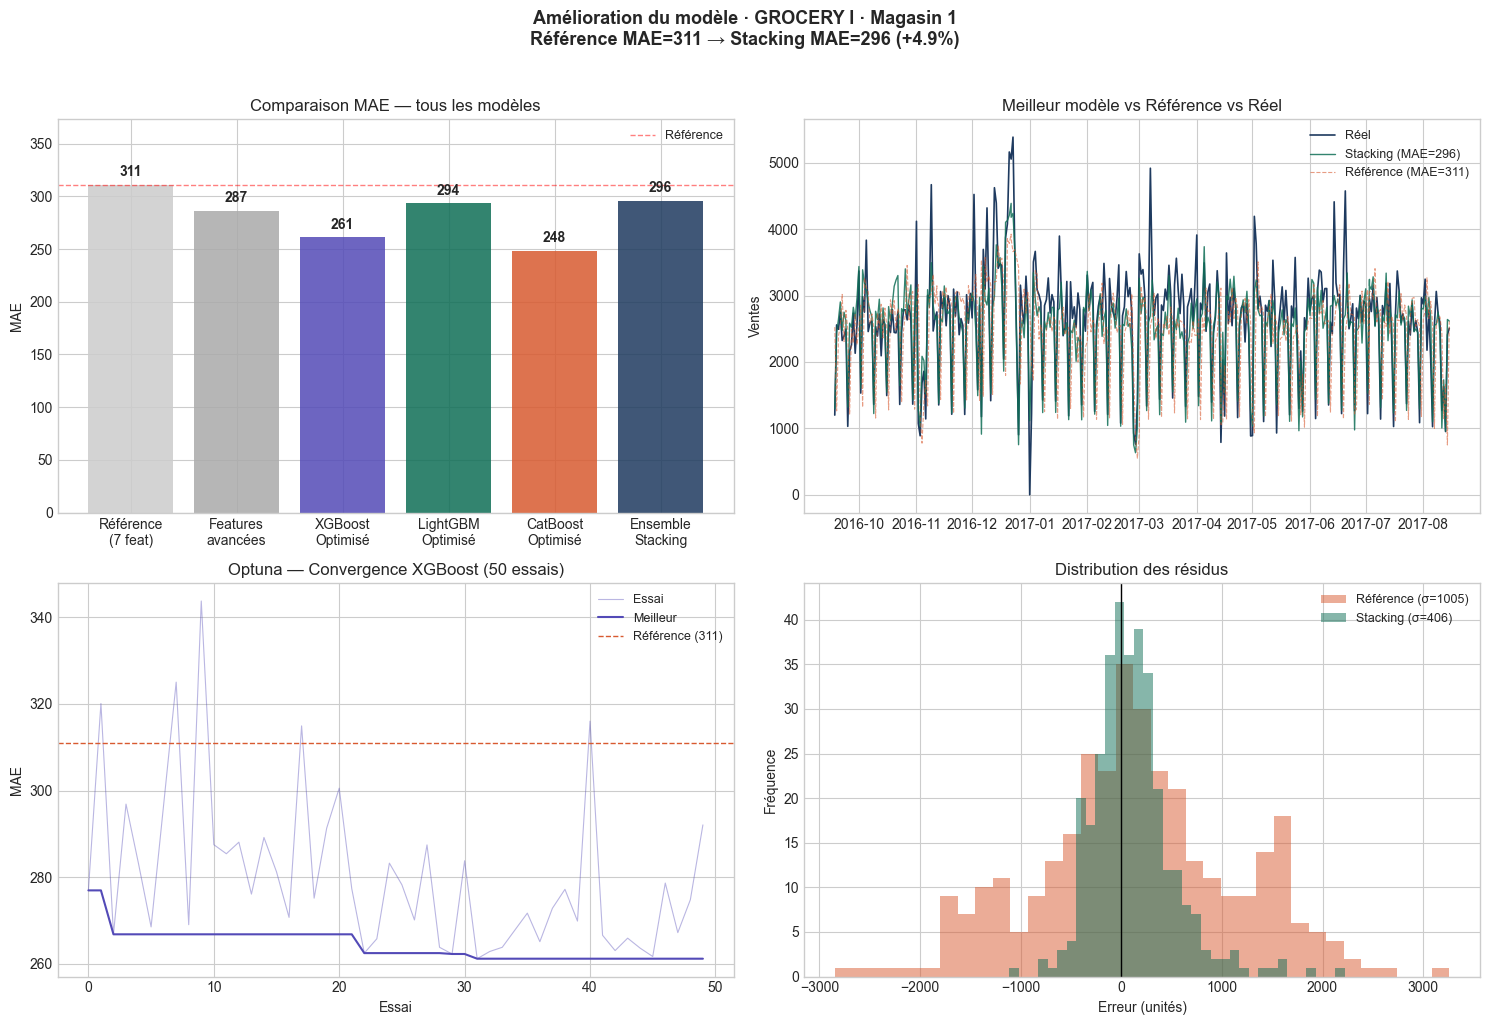


Ensemble sauvegardé → models/ensemble_final.pkl


In [ ]:

# Déterminer le meilleur ensemble
best_pred = pred_stacked  # à ajuster selon tes résultats

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ─── Graphique 1 : Comparaison MAE ───────────────────────────
models_names = ['Référence\n(7 feat)', 'Features\navancées',
                'XGBoost\nOptimisé', 'LightGBM\nOptimisé',
                'CatBoost\nOptimisé', 'Ensemble\nStacking']
maes_all = [mae_ref, mae_adv, mae_xgb_opt, mae_lgbm, mae_cat, mae_stacked]
colors_bar = ['#CCCCCC','#AAAAAA','#534AB7','#0F6E56','#D85A30','#1E3A5F']

bars = axes[0,0].bar(models_names, maes_all, color=colors_bar, alpha=0.85)
axes[0,0].bar_label(bars, fmt='%.0f', padding=4, fontsize=10, fontweight='bold')
axes[0,0].set_title('Comparaison MAE — tous les modèles', fontsize=12)
axes[0,0].set_ylabel('MAE')
axes[0,0].set_ylim(0, max(maes_all) * 1.2)
# Ligne de référence
axes[0,0].axhline(mae_ref, color='red', linewidth=1,
                  linestyle='--', alpha=0.5, label='Référence')
axes[0,0].legend(fontsize=9)

# ─── Graphique 2 : Prédictions vs Réel (meilleur modèle) ────
axes[0,1].plot(y_te_adv.index, y_te_adv.values,
               label='Réel', color='#1E3A5F', linewidth=1.2)
axes[0,1].plot(y_te_adv.index, best_pred,
               label=f'Stacking (MAE={mae_stacked:.0f})',
               color='#0F6E56', linewidth=1, alpha=0.85)
axes[0,1].plot(y_te_adv.index, m_ref.predict(X_te_b[:len(y_te_adv)]),
               label=f'Référence (MAE={mae_ref:.0f})',
               color='#D85A30', linewidth=0.8, linestyle='--', alpha=0.6)
axes[0,1].set_title('Meilleur modèle vs Référence vs Réel', fontsize=12)
axes[0,1].set_ylabel('Ventes')
axes[0,1].legend(fontsize=9)

# ─── Graphique 3 : Optuna — Historique d'optimisation XGBoost
trials_vals = [t.value for t in study_xgb.trials if t.value is not None]
best_so_far = np.minimum.accumulate(trials_vals)
axes[1,0].plot(trials_vals, alpha=0.4, color='#534AB7', linewidth=0.8, label='Essai')
axes[1,0].plot(best_so_far, color='#534AB7', linewidth=1.5, label='Meilleur')
axes[1,0].axhline(mae_ref, color='#D85A30', linestyle='--',
                  linewidth=1, label=f'Référence ({mae_ref:.0f})')
axes[1,0].set_title('Optuna — Convergence XGBoost (50 essais)', fontsize=12)
axes[1,0].set_xlabel('Essai')
axes[1,0].set_ylabel('MAE')
axes[1,0].legend(fontsize=9)

# ─── Graphique 4 : Résidus comparés ─────────────────────────
res_ref  = y_te_adv.values - m_ref.predict(X_te_b[:len(y_te_adv)])
res_best = y_te_adv.values - best_pred

axes[1,1].hist(res_ref,  bins=35, alpha=0.5, color='#D85A30', label=f'Référence (σ={np.std(res_ref):.0f})')
axes[1,1].hist(res_best, bins=35, alpha=0.5, color='#0F6E56', label=f'Stacking (σ={np.std(res_best):.0f})')
axes[1,1].axvline(0, color='black', linewidth=1)
axes[1,1].set_title('Distribution des résidus', fontsize=12)
axes[1,1].set_xlabel('Erreur (unités)')
axes[1,1].set_ylabel('Fréquence')
axes[1,1].legend(fontsize=9)

plt.suptitle(f'Amélioration du modèle · GROCERY I · Magasin 1\n'
             f'Référence MAE={mae_ref:.0f} → Stacking MAE={mae_stacked:.0f} '
             f'({(mae_ref-mae_stacked)/mae_ref*100:+.1f}%)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('resultats_model_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarder le meilleur modèle
import joblib, os
os.makedirs('../models', exist_ok=True)
joblib.dump({'xgb': m_xgb_final, 'lgbm': m_lgbm_final,
             'cat': m_cat_final, 'meta': meta, 'poids': poids},
            '../models/ensemble_final.pkl')
print("\nEnsemble sauvegardé → models/ensemble_final.pkl")